In [ ]:
# Paso 1: Importar las librerías necesarias para el análisis y visualización
# pandas: para manipulación y análisis de datos
import pandas as pd
# matplotlib: para visualización de datos
import matplotlib.pyplot as plt
# seaborn: para visualización de datos estadísticos
import seaborn as sns

In [4]:
# Paso 2: Cargar, limpiar y pivotar los datos

# 2.1 Cargar el archivo omitiendo la primera fila y usando encoding latin1
file_path = "SYB66_246_202310_Population Growth, Fertility and Mortality Indicators.csv"
df = pd.read_csv(file_path, skiprows=1, encoding='latin1')

# 2.2 Renombrar la columna sin nombre a "Country"
df.rename(columns={'Unnamed: 1': 'Country'}, inplace=True)

# 2.3 Filtrar solo para el año 2020
df_2020 = df[df['Year'] == 2020].copy()

# 2.4 Limpiar los números (quitar comas) y convertirlos a formato numérico
df_2020['Value'] = pd.to_numeric(df_2020['Value'].astype(str).str.replace(',', ''), errors='coerce')

# 2.5 Crear la tabla pivote para tener los indicadores como columnas
df_pivot = df_2020.pivot_table(index='Country', columns='Series', values='Value', aggfunc='mean')

# Mostramos las primeras filas para comprobar que todo está en orden
df_pivot.head(3)

Series,"Infant mortality for both sexes (per 1,000 live births)",Life expectancy at birth for both sexes (years),Life expectancy at birth for females (years),Life expectancy at birth for males (years),"Maternal mortality ratio (deaths per 100,000 population)",Population annual rate of increase (percent),Total fertility rate (children per women)
Country,,,,,,,
Afghanistan,45.8,62.6,65.4,59.9,620.0,3.3,4.8
Africa,46.4,62.2,64.2,60.3,487.0,2.4,4.4
Albania,8.8,77.0,79.7,74.6,8.0,-0.4,1.4


In [5]:
# Paso 3: Crear una función para generar el gráfico de dispersión
def graficar_dispersion(datos):
    x_col = 'Infant mortality for both sexes (per 1,000 live births)'
    y_col = 'Life expectancy at birth for both sexes (years)'

    plt.figure(figsize=(10, 6))
    # Aquí cambiamos el color a azul puro
    sns.scatterplot(data=datos, x=x_col, y=y_col, color='blue', alpha=0.7)
    
    plt.title('Relación: Mortalidad Infantil vs Esperanza de Vida (2020)', fontsize=14, pad=15)
    plt.xlabel('Mortalidad Infantil (por cada 1,000 nacidos vivos)', fontsize=12)
    plt.ylabel('Esperanza de Vida (años)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Guardamos la imagen
    plt.savefig('grafico_dispersion_patrick.jpg', dpi=300)
    plt.show()

In [6]:
# Paso 4: Crear una función para generar el mapa de calor de correlaciones
def graficar_correlacion(datos):
    corr_matrix = datos.corr()

    plt.figure(figsize=(12, 8))
    # Usamos el mapa de color 'Blues' para mantener la paleta azul
    sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5, 
                cbar_kws={'label': 'Coeficiente de Correlación'})
    
    plt.title('Matriz de Correlación de Indicadores Demográficos (2020)', fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Guardamos la imagen
    plt.savefig('grafico_correlacion_patrick.jpg', dpi=300)
    plt.show()

--- Generando Gráfico de Dispersión ---


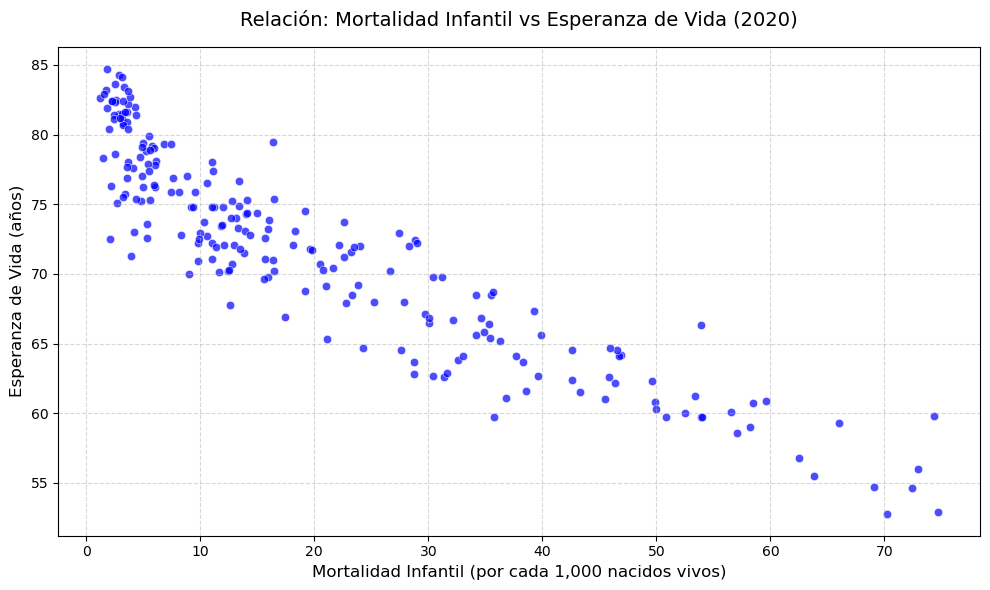


--- Generando Matriz de Correlación ---


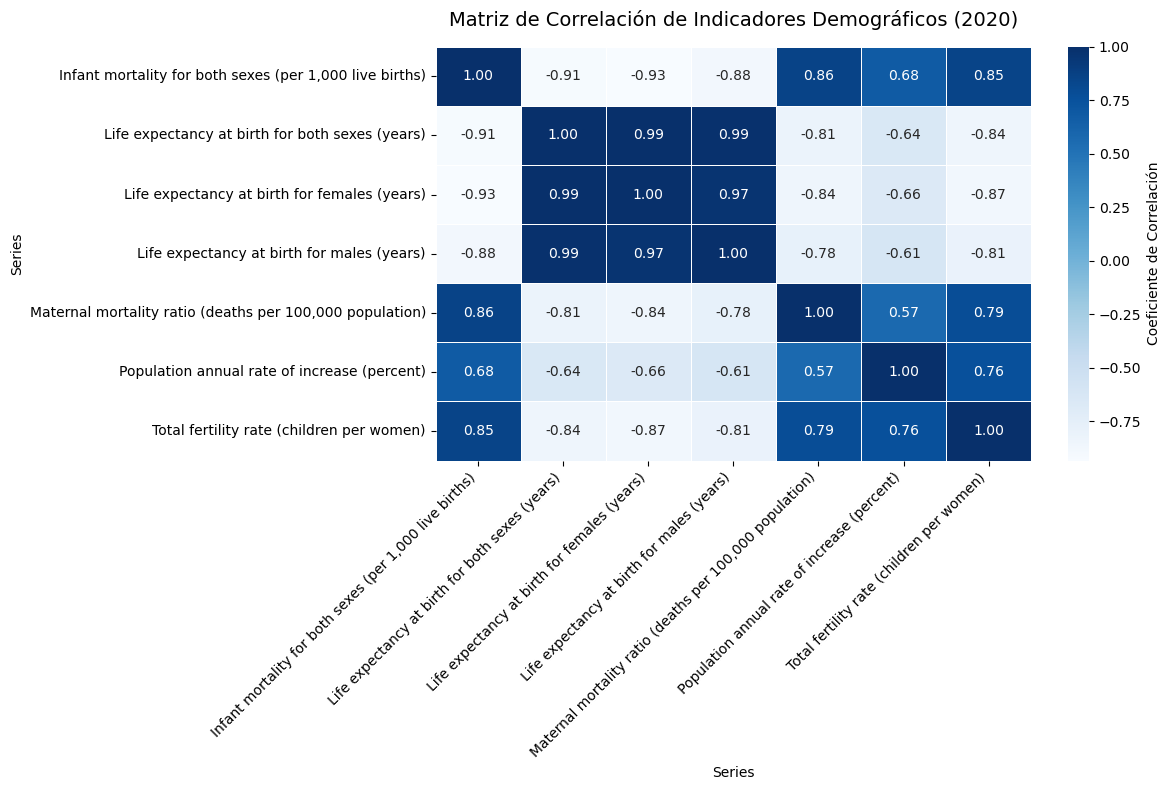

In [7]:
# Paso 5: Llamar a las funciones definidas para visualizar los resultados finales

print("--- Generando Gráfico de Dispersión ---")
graficar_dispersion(df_pivot)

print("\n--- Generando Matriz de Correlación ---")
graficar_correlacion(df_pivot)